In [ ]:
!pip -q install pyspark graphviz
!apt-get -q install graphviz -y


Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Shopping Trends And Customer Behaviour Dataset.csv to Shopping Trends And Customer Behaviour Dataset.csv


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CustomerMetricsBuyingTrends") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark started")


Spark started


In [ ]:
#Load CSV and Clean Columns
file_name = "Shopping Trends And Customer Behaviour Dataset.csv"

df = spark.read.csv(
    file_name,
    header=True,
    inferSchema=True,
    sep=","
)

print("Raw columns:")
print(df.columns)

import re
for c in df.columns:
    new_c = re.sub(r'[^0-9a-zA-Z_]', '_', c).strip('_')
    df = df.withColumnRenamed(c, new_c)

print("Cleaned columns:")
print(df.columns)

df.show(5)


Raw columns:
['_c0', 'Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']
Cleaned columns:
['c0', 'Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase_Amount__USD', 'Location', 'Color', 'Season', 'Review_Rating', 'Subscription_Status', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method', 'Frequency_of_Purchases']
+---+-----------+---+------+--------------+--------+--------------------+-------------+---------+------+-------------+-------------------+-------------+----------------+---------------+------------------+--------------+----------------------+
| c0|Customer_ID|Age|Gender|Item_Purchased|Category|Purchase_Amount__USD|     Location|    Color|Season|Review_Rating|Subscription_Status|Shipping_Type|D

In [ ]:
#Drop Useless Columns
# Drop index-like column if present
if "Unnamed_0" in df.columns:
    df = df.drop("Unnamed_0")

# Define label column (Buying trend / loyalty)
label_col = "Subscription_Status"

# Remove rows with missing label
df = df.dropna(subset=[label_col])

print("After dropping index & null labels")
df.select(label_col).show(5)


✅ After dropping index & null labels
+-------------------+
|Subscription_Status|
+-------------------+
|                Yes|
|                Yes|
|                Yes|
|                Yes|
|                Yes|
+-------------------+
only showing top 5 rows


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

# Identify numeric vs categorical columns
all_cols = [c for c in df.columns if c != label_col]

numeric_cols = []
categorical_cols = []

for c in all_cols:
    dtype = dict(df.dtypes)[c]
    if dtype in ("int", "bigint", "double", "float"):
        numeric_cols.append(c)
    else:
        categorical_cols.append(c)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Index label (Yes/No -> 0/1)
label_indexer = StringIndexer(inputCol=label_col, outputCol="label", handleInvalid="keep")

# Index categorical features
indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in categorical_cols
]

# One-hot encode indexed categorical features
encoder = OneHotEncoder(
    inputCols=[c+"_idx" for c in categorical_cols],
    outputCols=[c+"_ohe" for c in categorical_cols],
    handleInvalid="keep"
)

# Assemble all features into one vector column
assembler_inputs = numeric_cols + [c+"_ohe" for c in categorical_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_raw")

# Scale features (recommended for neural networks)
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False)

pipeline = Pipeline(stages=[label_indexer] + indexers + [encoder, assembler, scaler])

prepared = pipeline.fit(df).transform(df)

final_df = prepared.select("features", "label")
final_df.show(5, truncate=False)


Numeric columns: ['c0', 'Customer_ID', 'Age', 'Purchase_Amount__USD', 'Review_Rating', 'Previous_Purchases']
Categorical columns: ['Gender', 'Item_Purchased', 'Category', 'Location', 'Color', 'Season', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Payment_Method', 'Frequency_of_Purchases']
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                                                                                                                                                                                          

In [ ]:
#Splitting the dataset to training and testing

train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)
print("Training Count:", train_df.count())
print("Testing  Count:", test_df.count())


Training Count: 3177
Testing  Count: 723


In [ ]:
#Model Training

from pyspark.ml.classification import MultilayerPerceptronClassifier

# Determine number of input features
input_size = len(train_df.select("features").first()[0])
print("Input layer size:", input_size)

layers = [input_size, 16, 8, 2]

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=layers,
    maxIter=120,
    seed=42,
    blockSize=128
)

model = mlp.fit(train_df)
print("Model trained")


Input layer size: 150
Model trained


In [ ]:
#Make predictions
predictions = model.transform(test_df)
predictions.select("label", "prediction", "probability").show(10, truncate=False)

+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|0.0  |0.0       |[1.0,2.269787738257928E-23]               |
|0.0  |0.0       |[1.0,2.0835030249962254E-23]              |
|0.0  |0.0       |[1.0,2.269447931370267E-23]               |
|0.0  |0.0       |[1.0,2.2698095027143026E-23]              |
|0.0  |0.0       |[1.0,1.866000295069375E-22]               |
|0.0  |0.0       |[1.0,4.5709834997624575E-23]              |
|1.0  |1.0       |[3.394690336334028E-13,0.9999999999996605]|
|0.0  |0.0       |[1.0,5.599438155825376E-23]               |
|0.0  |0.0       |[1.0,2.2697882810500982E-23]              |
|0.0  |0.0       |[1.0,2.26978795939398E-23]                |
+-----+----------+------------------------------------------+
only showing top 10 rows


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
    )

prec_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
    )

rec_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
    )

accuracy = acc_eval.evaluate(predictions)
precision = prec_eval.evaluate(predictions)
recall = rec_eval.evaluate(predictions)

print("Metrics")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)


Metrics
Accuracy : 0.979253112033195
Precision: 0.9792519724520921
Recall   : 0.9792531120331951


In [ ]:
#Fine Tuning the Model to get more accurate

mlp_tuned = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_size, 24, 12, 2],
    maxIter=180,
    seed=42
)

tuned_model = mlp_tuned.fit(train_df)
tuned_preds = tuned_model.transform(test_df)

tuned_accuracy = acc_eval.evaluate(tuned_preds)
print("Tuned Model Accuracy:", tuned_accuracy)


Tuned Model Accuracy: 0.9737206085753803


In [ ]:
from pyspark.ml.classification import MultilayerPerceptronClassificationModel
import os, shutil

model_path = "fashion_mlp_model"

# Remove old model folder if exists
if os.path.exists(model_path):
    shutil.rmtree(model_path)

model.save(model_path)
print("Model saved:", model_path)

loaded_model = MultilayerPerceptronClassificationModel.load(model_path)
print("Model loaded successfully")


Model saved: fashion_mlp_model
Model loaded successfully


In [ ]:
#Inferencing using loaded model

loaded_predictions = loaded_model.transform(test_df)

print("Loaded model predictions")
loaded_predictions.select("label", "prediction").show(10)

print("Prediction distribution")
loaded_predictions.groupBy("prediction").count().show()


Loaded model predictions
+-----+----------+
|label|prediction|
+-----+----------+
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  1.0|       1.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 10 rows
Prediction distribution
+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|  531|
|       1.0|  192|
+----------+-----+



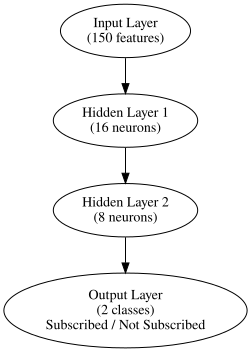

In [ ]:
#Visualizing the output with digraph
from graphviz import Digraph

dot = Digraph(name="Fashion Retail MLP", format="png")

dot.node("Input", f"Input Layer\n({input_size} features)")
dot.node("H1", "Hidden Layer 1\n(16 neurons)")
dot.node("H2", "Hidden Layer 2\n(8 neurons)")
dot.node("Output", "Output Layer\n(2 classes)\nSubscribed / Not Subscribed")

dot.edge("Input", "H1")
dot.edge("H1", "H2")
dot.edge("H2", "Output")

dot.render("fashion_mlp_network", cleanup=True)
dot


In [ ]:
#Download the image as png

from google.colab import files
files.download("fashion_mlp_network.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>